In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/student_depression_ml.csv")

df_ml.head()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Financial Stress__missing,Gender_male,City_agra,City_ahmedabad,City_bangalore,City_bhavna,City_bhopal,City_chennai,City_city,City_delhi,City_faridabad,City_gaurav,City_ghaziabad,City_harsh,City_harsha,City_hyderabad,City_indore,City_jaipur,City_kalyan,City_kanpur,City_khaziabad,City_kibara,City_kolkata,City_less delhi,City_less than 5 kalyan,City_lucknow,City_ludhiana,City_m.com,City_m.tech,City_me,City_meerut,City_mihir,City_mira,City_mumbai,City_nagpur,City_nalini,City_nalyan,City_nandini,City_nashik,City_patna,City_pune,City_rajkot,City_rashi,City_reyansh,City_saanvi,City_srinagar,City_surat,City_thane,City_vaanya,City_vadodara,City_varanasi,City_vasai-virar,City_visakhapatnam,Profession_chef,Profession_civil engineer,Profession_content writer,Profession_digital marketer,Profession_doctor,Profession_educational consultant,Profession_entrepreneur,Profession_lawyer,Profession_manager,Profession_pharmacist,Profession_student,Profession_teacher,Profession_ux/ui designer,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Degree_b.com,Degree_b.ed,Degree_b.pharm,Degree_b.tech,Degree_ba,Degree_bba,Degree_bca,Degree_be,Degree_bhm,Degree_bsc,Degree_class 12,Degree_llb,Degree_llm,Degree_m.com,Degree_m.ed,Degree_m.pharm,Degree_m.tech,Degree_ma,Degree_mba,Degree_mbbs,Degree_mca,Degree_md,Degree_me,Degree_mhm,Degree_msc,Degree_others,Degree_phd,Have you ever had suicidal thoughts ?_yes,Family History of Mental Illness_yes,Depression_yes
0,33,5,0,8,2,0,3,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1
1,24,2,0,5,5,0,3,2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,31,3,0,7,5,0,9,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,28,3,0,5,2,0,4,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
4,25,4,0,8,3,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0


In [3]:
# Target variable: depression (1 (Yes) vs 0 (No))
X = df_ml.drop(columns=["Depression_yes"])
y = df_ml["Depression_yes"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.79      0.84      0.81      2313
           1       0.88      0.84      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581

Macro F1: 0.8371422095673814
Weighted F1: 0.8412666773171021


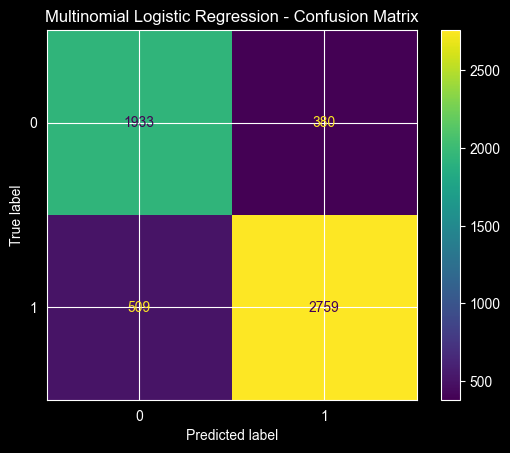

In [6]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# F1-score
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()

In [7]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.78      0.80      0.79      2313
           1       0.86      0.84      0.85      3268

    accuracy                           0.82      5581
   macro avg       0.82      0.82      0.82      5581
weighted avg       0.82      0.82      0.82      5581

Decision Tree Macro F1: 0.8176435517476899
Decision Tree Weighted F1: 0.8225078444937713


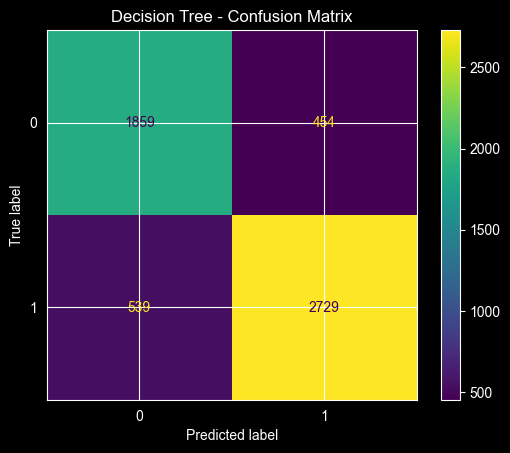

In [8]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_tree))

macro_f1_tree = f1_score(y_test, y_pred_tree, average="macro")
weighted_f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("Decision Tree Macro F1:", macro_f1_tree)
print("Decision Tree Weighted F1:", weighted_f1_tree)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

Have you ever had suicidal thoughts ?_yes    0.564273
Academic Pressure                            0.253790
Financial Stress                             0.105555
Age                                          0.042521
Work/Study Hours                             0.016606
Study Satisfaction                           0.008119
Dietary Habits_Unhealthy                     0.008042
City_mumbai                                  0.000624
Dietary Habits_Moderate                      0.000349
City_surat                                   0.000121
Job Satisfaction                             0.000000
CGPA                                         0.000000
Financial Stress__missing                    0.000000
Gender_male                                  0.000000
City_bhavna                                  0.000000
dtype: float64


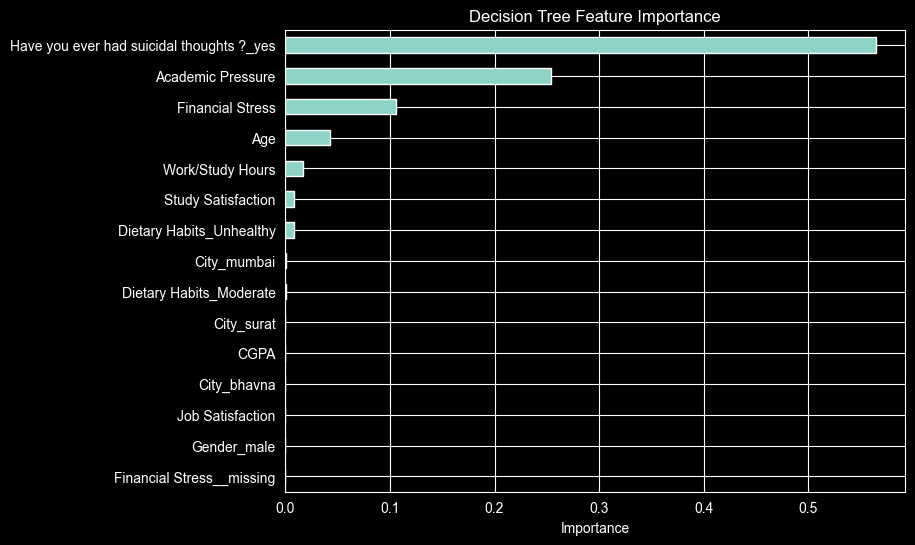

In [9]:
import pandas as pd

tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(tree_importance.head(15))
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

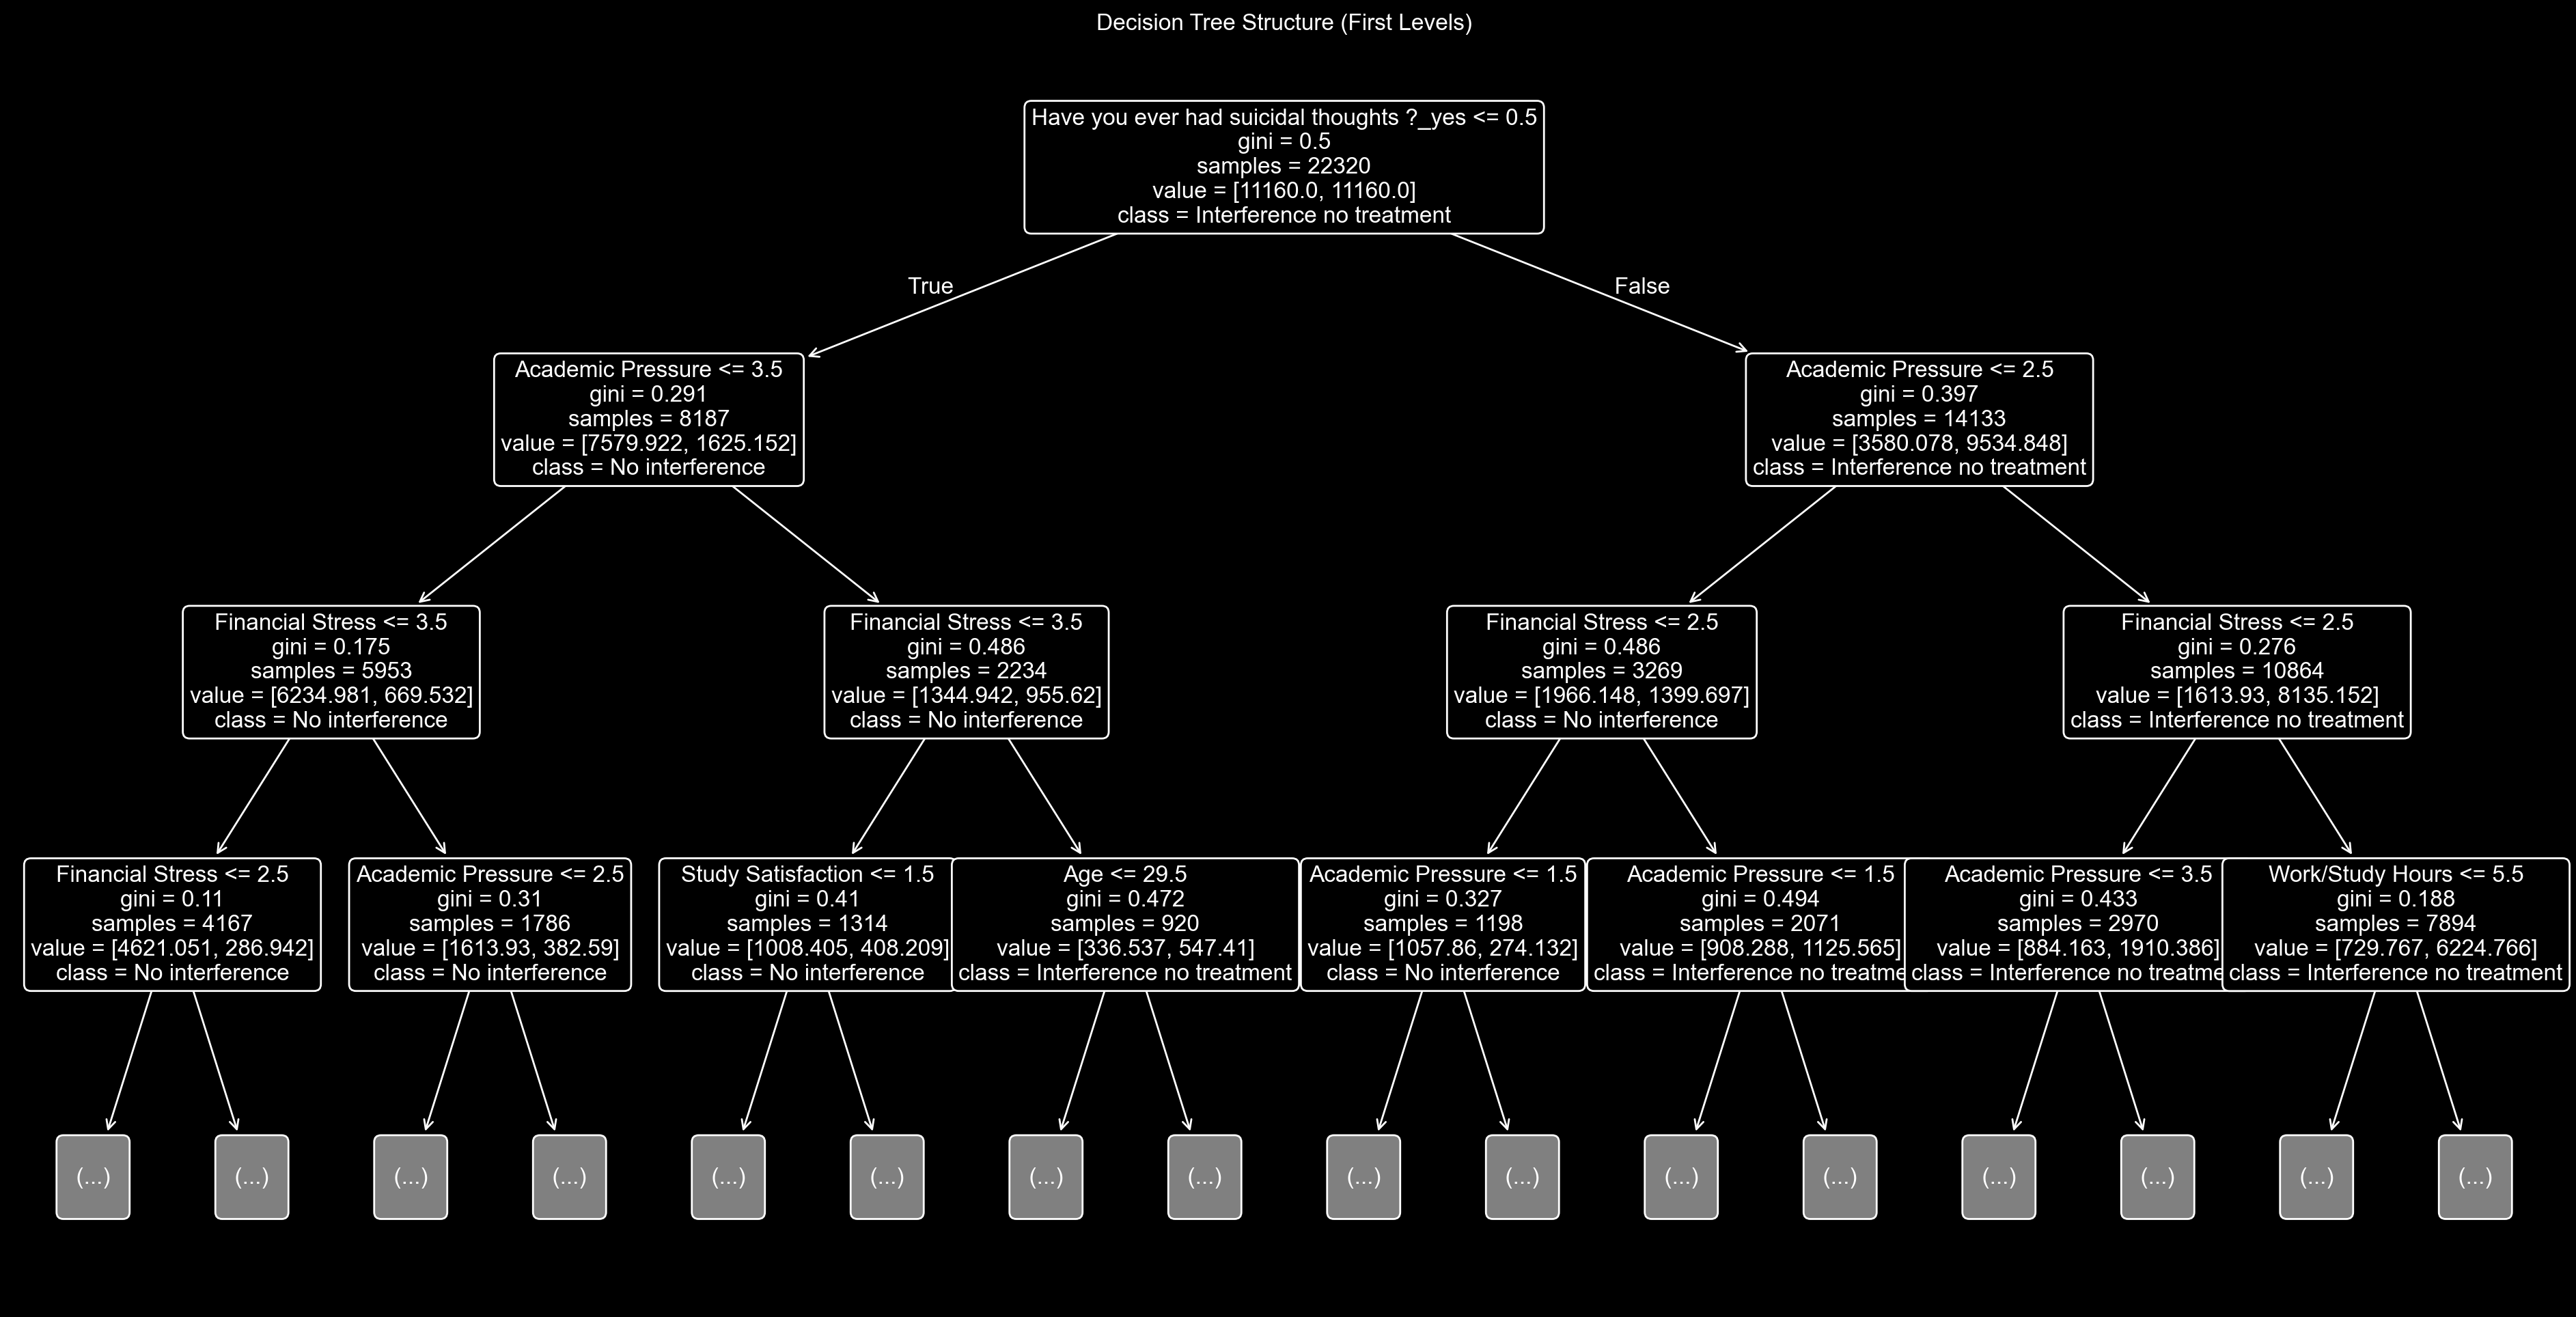

In [10]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12), dpi=200)

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No interference","Interference no treatment","Interference + treatment"],
    rounded=True,
    max_depth=3,
    fontsize=12
)

plt.title("Decision Tree Structure (First Levels)")
plt.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      2313
           1       0.87      0.86      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581

Random Forest Macro F1: 0.8378485743241797
Random Forest Weighted F1: 0.8424572891086027


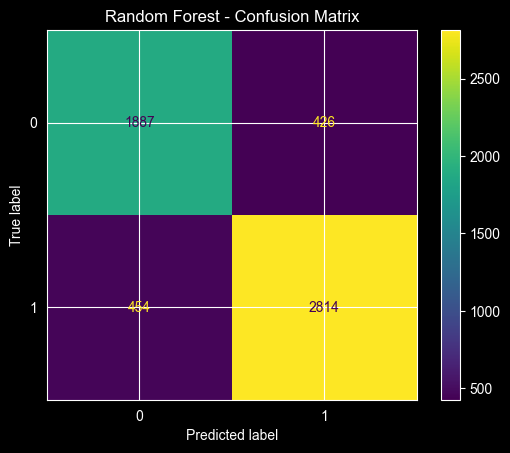

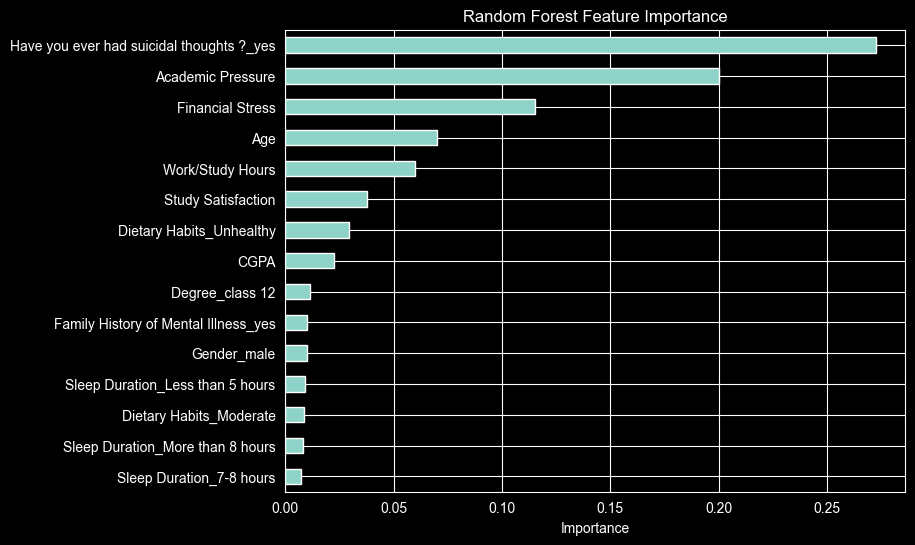

In [9]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

print(classification_report(y_test, y_pred_rf))

macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")
weighted_f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Macro F1:", macro_f1_rf)
print("Random Forest Weighted F1:", weighted_f1_rf)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.show()

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

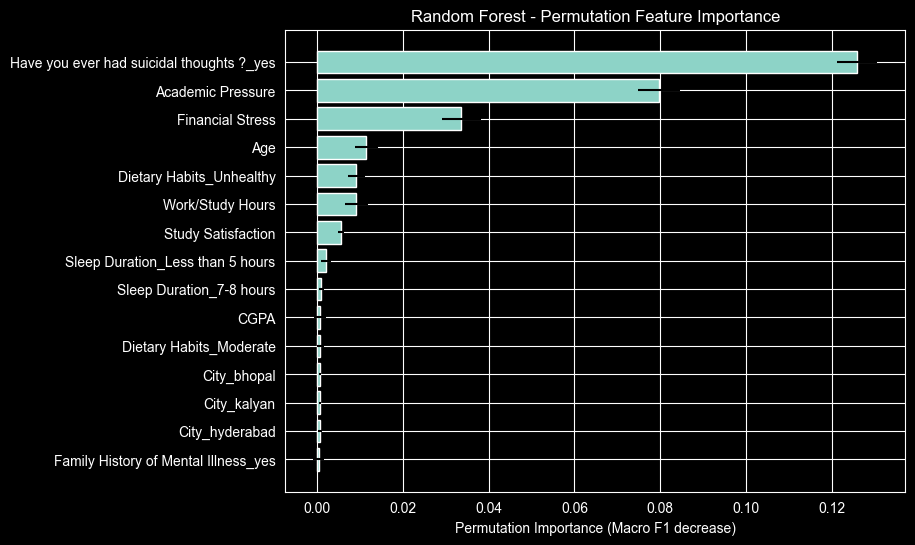

In [10]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

perm_importance_df.head(15)

top_features = perm_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Random Forest - Permutation Feature Importance")
plt.show()

In [5]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2313
           1       0.86      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581

XGBoost Macro F1: 0.837426018030212
XGBoost Weighted F1: 0.8425950489034176


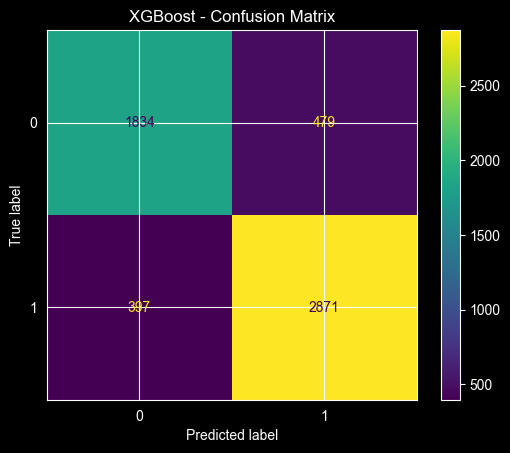

In [6]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_xgb))

macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print("XGBoost Macro F1:", macro_f1_xgb)
print("XGBoost Weighted F1:", weighted_f1_xgb)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.show()

Have you ever had suicidal thoughts ?_yes    0.390808
Academic Pressure                            0.107345
Financial Stress                             0.051824
Dietary Habits_Unhealthy                     0.024434
Age                                          0.020549
Work/Study Hours                             0.017247
Study Satisfaction                           0.015887
Dietary Habits_Moderate                      0.015069
Sleep Duration_More than 8 hours             0.010944
Sleep Duration_Less than 5 hours             0.010908
Family History of Mental Illness_yes         0.008661
Degree_ma                                    0.007650
City_hyderabad                               0.007044
City_patna                                   0.006963
City_ahmedabad                               0.006944
dtype: float32


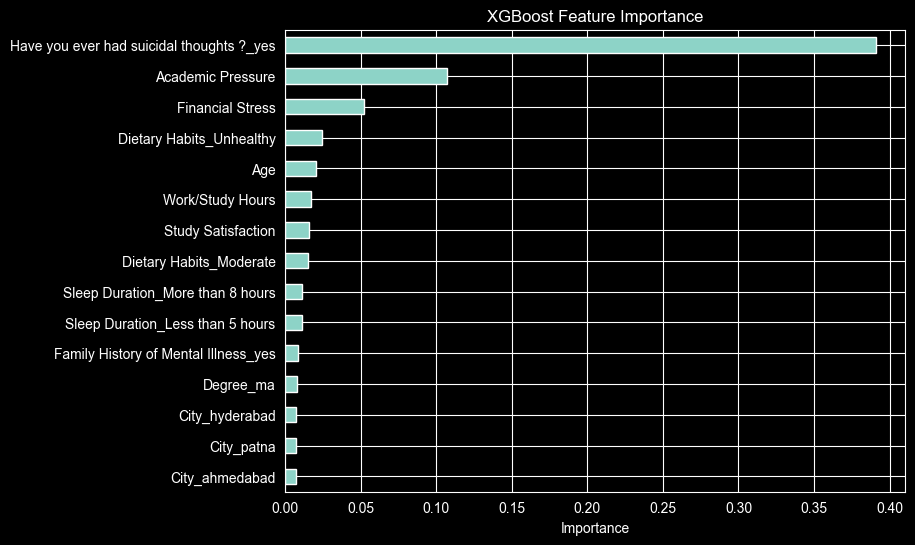

In [7]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

                                       feature  importance_mean  \
108  Have you ever had suicidal thoughts ?_yes         0.111579   
1                            Academic Pressure         0.084040   
7                             Financial Stress         0.034873   
0                                          Age         0.014922   
80                    Dietary Habits_Unhealthy         0.009181   
6                             Work/Study Hours         0.008463   
4                           Study Satisfaction         0.004167   
76            Sleep Duration_More than 8 hours         0.000821   
23                              City_hyderabad         0.000607   
85                                   Degree_ba         0.000402   
24                                 City_indore         0.000353   
78                     Dietary Habits_Moderate         0.000339   
82                                 Degree_b.ed         0.000310   
11                              City_ahmedabad         0.00027

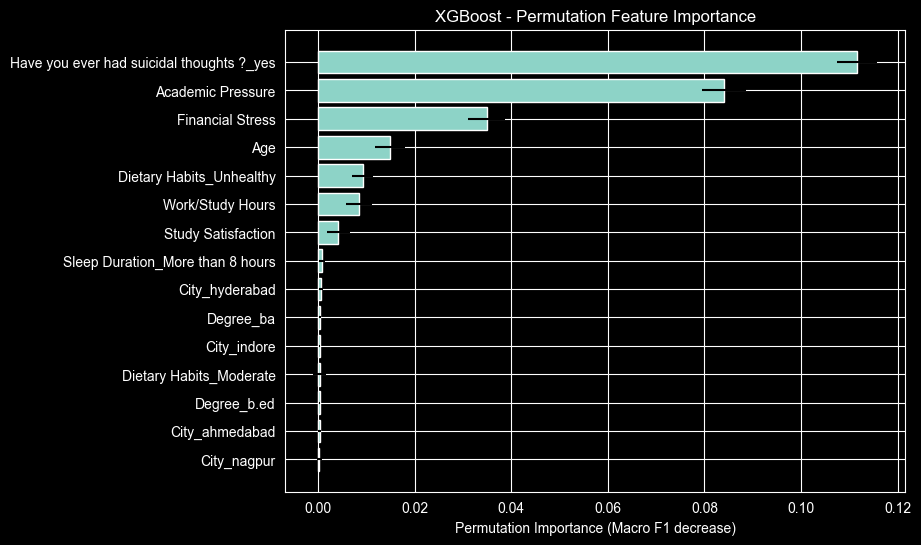

In [12]:
from sklearn.inspection import permutation_importance

perm_xgb = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=4
)

perm_xgb_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_xgb_df.head(15))

top_features = perm_xgb_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("XGBoost - Permutation Feature Importance")
plt.show()